# Crop Disease Detection — Tomato + Grape (v3)

Pipeline: pretrain on PlantVillage (lab photos) -> fine-tune on PlantDoc (real field photos) -> evaluate on PlantDoc -> Grad-CAM bounding box for visualizing the diseased region.

**What's new in this version:**
- An architecture bake-off (ResNet50 vs EfficientNetV2-S vs MobileNetV3) run on your actual data before committing to full training, instead of picking one from literature alone.
- A bug fix: earlier versions were missing ImageNet normalization on the input images — pretrained backbones expect it, and skipping it silently hurts accuracy. Fixed here.
- Fixed random seeds + a data-integrity sanity check before training starts, so a bad download/filter step fails loudly instead of quietly producing bad results.
- Grad-CAM based bounding boxes: draws a box around the region the model actually used to make its diagnosis — see the caveat in that section, this is not a trained object detector.
- Everything still checkpoints to Drive every epoch and auto-resumes after a disconnect (see the earlier explanation if this is your first time here).

Runtime > Change runtime type > T4 GPU, before running anything below.

In [ ]:
import torch, random, numpy as np
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Using:", torch.cuda.get_device_name(0))
else:
    print("Go to Runtime > Change runtime type > select T4 GPU, then re-run this cell.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print("Seeds fixed at", SEED, "- re-running the notebook should give consistent results.")


GPU available: True
Using: Tesla T4
Seeds fixed at 42 - re-running the notebook should give consistent results.


## 1. Mount Drive — checkpoints, logs, and cached dataset all live here

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

PROJECT_DIR = '/content/drive/MyDrive/crop-disease-model'
CKPT_DIR    = f'{PROJECT_DIR}/checkpoints'
DATA_CACHE  = f'{PROJECT_DIR}/data_cache'
for d in [PROJECT_DIR, CKPT_DIR, DATA_CACHE]:
    os.makedirs(d, exist_ok=True)
print("Everything persists under:", PROJECT_DIR)


Mounted at /content/drive
Everything persists under: /content/drive/MyDrive/crop-disease-model


## 2. Install dependencies

In [ ]:
!pip install -q kagglehub timm scikit-learn grad-cam opencv-python-headless


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 3. Get the dataset — from Drive cache if it exists, otherwise download fresh

First run: downloads + filters to Tomato/Grape, then caches to Drive. Every run after a disconnect: unzips from Drive in seconds.

In [ ]:
import shutil, glob, zipfile

DATA_DIR = "/content/data"
CACHE_ZIP = f"{DATA_CACHE}/tomato_grape_filtered_v3.zip"   # v3 = PlantDoc train/test kept separate (field_finetune vs field_eval); older caches auto-rebuild

def cache_looks_valid():
    return (os.path.isdir(f"{DATA_DIR}/train/tomato") and os.path.isdir(f"{DATA_DIR}/train/grape")
            and os.path.isdir(f"{DATA_DIR}/field_finetune/tomato") and os.path.isdir(f"{DATA_DIR}/field_finetune/grape"))

used_cache = False
if os.path.exists(CACHE_ZIP):
    print("Found cached filtered dataset on Drive - restoring (fast).")
    with zipfile.ZipFile(CACHE_ZIP) as zf:
        zf.extractall("/content")
    if cache_looks_valid():
        used_cache = True
        print("Restored to", DATA_DIR)
    else:
        print("Cached data is missing or old-format - rebuilding from scratch.")
        shutil.rmtree(DATA_DIR, ignore_errors=True)

if not used_cache:
    print("Downloading + filtering from scratch (this only happens once)...")

    import kagglehub
    pv_path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
    train_dirs = glob.glob(pv_path + "/**/train", recursive=True)
    valid_dirs = glob.glob(pv_path + "/**/valid", recursive=True)
    if not train_dirs or not valid_dirs:
        raise RuntimeError(
            "Could not find train/valid folders in the downloaded PlantVillage dataset. "
            "Print glob.glob(pv_path + '/**', recursive=True) and inspect the actual folder layout - "
            "Kaggle occasionally changes the nesting of this dataset."
        )
    PV_TRAIN, PV_VALID = train_dirs[0], valid_dirs[0]

    def filter_crop_folders(src_dir, dst_dir, keywords):
        os.makedirs(dst_dir, exist_ok=True)
        kept = []
        for folder in sorted(glob.glob(f"{src_dir}/*")):
            name = os.path.basename(folder)
            if any(k in name for k in keywords):
                shutil.copytree(folder, f"{dst_dir}/{name}", dirs_exist_ok=True)
                kept.append(name)
        print(f"{dst_dir}: kept {len(kept)} classes")
        return kept

    for split, src in [("train", PV_TRAIN), ("valid", PV_VALID)]:
        filter_crop_folders(src, f"{DATA_DIR}/{split}/tomato", ("Tomato", "tomato"))
        filter_crop_folders(src, f"{DATA_DIR}/{split}/grape", ("Grape", "grape"))

    !rm -rf /content/plantdoc
    !git clone --quiet --filter=blob:none --sparse https://github.com/pratikkayal/PlantDoc-Dataset.git /content/plantdoc
    %cd /content/plantdoc
    !git sparse-checkout set "train/*Tomato*" "train/*tomato*" "train/*Grape*" "train/*grape*" "test/*Tomato*" "test/*tomato*" "test/*Grape*" "test/*grape*"
    %cd /content

    PLANTDOC_TO_PLANTVILLAGE = {
        "Tomato leaf bacterial spot":         "Tomato___Bacterial_spot",
        "Tomato Early blight leaf":           "Tomato___Early_blight",
        "Tomato leaf late blight":            "Tomato___Late_blight",
        "Tomato mold leaf":                   "Tomato___Leaf_Mold",
        "Tomato Septoria leaf spot":          "Tomato___Septoria_leaf_spot",
        "Tomato two spotted spider mites leaf": "Tomato___Spider_mites Two-spotted_spider_mite",
        "Tomato leaf yellow virus":           "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
        "Tomato leaf mosaic virus":           "Tomato___Tomato_mosaic_virus",
        "Tomato leaf":                        "Tomato___healthy",
        "grape leaf black rot":               "Grape___Black_rot",
        "grape leaf":                         "Grape___healthy",
        # No PlantDoc equivalent for: Tomato___Target_Spot,
        # Grape___Esca_(Black_Measles), Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
    }

    # PlantDoc ships its own train/test split - keep them separate.
    # train/ -> field_finetune (the model trains on this, closes the lab-to-field gap)
    # test/  -> field_eval (never trained on, this is the honest accuracy number)
    PLANTDOC_SPLIT_TO_OURS = {"train": "field_finetune", "test": "field_eval"}
    for pd_split, our_split in PLANTDOC_SPLIT_TO_OURS.items():
        for pd_name, pv_name in PLANTDOC_TO_PLANTVILLAGE.items():
            src = f"/content/plantdoc/{pd_split}/{pd_name}"
            if os.path.isdir(src):
                crop_dir = "tomato" if pv_name.startswith("Tomato") else "grape"
                dst = f"{DATA_DIR}/{our_split}/{crop_dir}/{pv_name}"
                os.makedirs(dst, exist_ok=True)
                for f in os.listdir(src):
                    shutil.copy(os.path.join(src, f), dst)

    print("Caching filtered dataset to Drive for next time...")
    shutil.make_archive(CACHE_ZIP.replace(".zip", ""), "zip", "/content", "data")
    print("Cached at", CACHE_ZIP)

FIELD_FINETUNE_DIR = f"{DATA_DIR}/field_finetune"
FIELD_EVAL_DIR = f"{DATA_DIR}/field_eval"
print("\nReady.")

Found cached filtered dataset on Drive - restoring (fast).
Restored to /content/data

Ready.


## 4. Sanity check — catch a bad download/filter *now*, not after an hour of training

Prints per-class image counts and previews a few images with their labels. If a class has 0 or a handful of images, or a label looks wrong, stop here and fix it — don't proceed into training on broken data.

=== Training set class counts ===
  train/tomato/Tomato___Bacterial_spot: 1702
  train/tomato/Tomato___Early_blight: 1920
  train/tomato/Tomato___Late_blight: 1851
  train/tomato/Tomato___Leaf_Mold: 1882
  train/tomato/Tomato___Septoria_leaf_spot: 1745
  train/tomato/Tomato___Spider_mites Two-spotted_spider_mite: 1741
  train/tomato/Tomato___Target_Spot: 1827
  train/tomato/Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1961
  train/tomato/Tomato___Tomato_mosaic_virus: 1790
  train/tomato/Tomato___healthy: 1926
  train/grape/Grape___Black_rot: 1888
  train/grape/Grape___Esca_(Black_Measles): 1920
  train/grape/Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722
  train/grape/Grape___healthy: 1692
  valid/tomato/Tomato___Bacterial_spot: 425
  valid/tomato/Tomato___Early_blight: 480
  valid/tomato/Tomato___Late_blight: 463
  valid/tomato/Tomato___Leaf_Mold: 470
  valid/tomato/Tomato___Septoria_leaf_spot: 436
  valid/tomato/Tomato___Spider_mites Two-spotted_spider_mite: 435
  valid/tomato/Tomato___

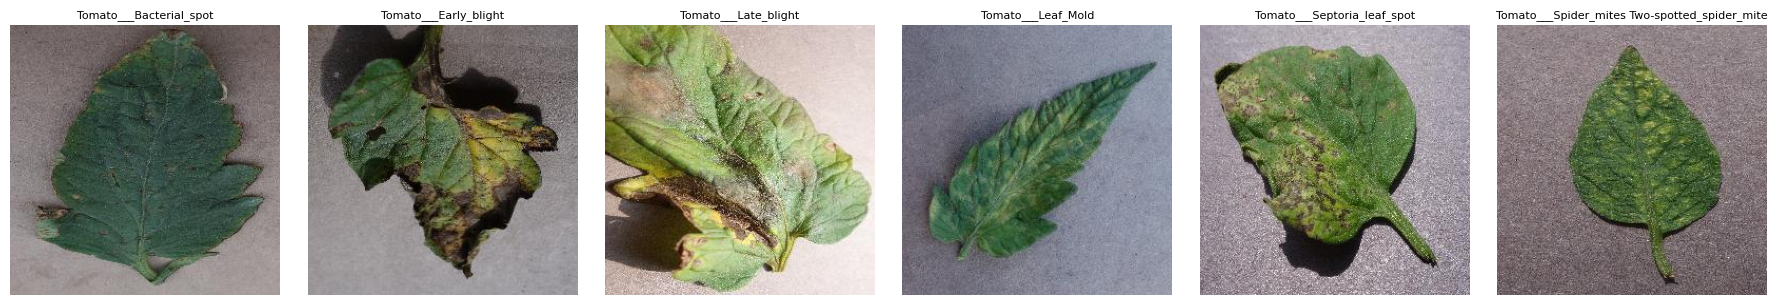

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage

print("=== Training set class counts ===")
problems = []
for split in ["train", "valid"]:
    for crop_dir in ["tomato", "grape"]:
        crop_path = f"{DATA_DIR}/{split}/{crop_dir}"
        if not os.path.isdir(crop_path):
            problems.append(f"{crop_path} is missing entirely")
            continue
        for cls in sorted(os.listdir(crop_path)):
            n = len(os.listdir(f"{crop_path}/{cls}"))
            print(f"  {split}/{crop_dir}/{cls}: {n}")
            if n < 20:
                problems.append(f"{split}/{crop_dir}/{cls} has only {n} images")

print("\n=== Field-eval (PlantDoc) class counts ===")
for crop_dir in ["tomato", "grape"]:
    crop_path = f"{FIELD_EVAL_DIR}/{crop_dir}"
    if os.path.isdir(crop_path):
        for cls in sorted(os.listdir(crop_path)):
            n = len(os.listdir(f"{crop_path}/{cls}"))
            print(f"  {crop_dir}/{cls}: {n}")

if problems:
    print("\n WARNING - these look too small / missing to train on reliably:")
    for p in problems:
        print("  -", p)
else:
    print("\nNo obvious problems found.")

sample_dir = f"{DATA_DIR}/train/tomato"
sample_classes = sorted(os.listdir(sample_dir))[:6]
fig, axes = plt.subplots(1, len(sample_classes), figsize=(18, 3))
for ax, cls in zip(axes, sample_classes):
    files = os.listdir(f"{sample_dir}/{cls}")
    img = PILImage.open(f"{sample_dir}/{cls}/{files[0]}")
    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Shared training setup — includes the normalization fix

In [ ]:
import timm, torch, torch.nn as nn, json
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),   # <-- the fix: pretrained backbones expect this
])
eval_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


## 6. Architecture bake-off

Trains the classifier head only (backbone frozen) for 2 quick epochs on each candidate, on your actual Tomato data — not a literature claim, an empirical check on your own dataset. Compares validation accuracy and time per epoch, then the winner is used for full training below.

In [8]:
import time

CANDIDATE_ARCHS = ["resnet50", "efficientnetv2_rw_s.ra2_in1k", "mobilenetv3_large_100"]

def quick_bakeoff_run(arch_name, crop_dir="tomato", epochs=2):
    train_ds = datasets.ImageFolder(f"{DATA_DIR}/train/{crop_dir}", train_tfm)
    val_ds   = datasets.ImageFolder(f"{DATA_DIR}/valid/{crop_dir}", eval_tfm)
    train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
    val_dl   = DataLoader(val_ds, batch_size=32, num_workers=2)

    model = timm.create_model(arch_name, pretrained=True, num_classes=len(train_ds.classes)).to(device)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.get_classifier().parameters():
        p.requires_grad = True
    opt = torch.optim.Adam(model.get_classifier().parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            loss = loss_fn(model(imgs), labels)
            loss.backward()
            opt.step()
    elapsed = time.time() - t0

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (model(imgs).argmax(1) == labels).sum().item()
            total += imgs.size(0)
    val_acc = correct / total
    return val_acc, elapsed / epochs

print(f"{'Architecture':<24} {'Val Acc (2 epochs)':<20} {'Time/epoch (s)'}")
bakeoff_results = {}
for arch in CANDIDATE_ARCHS:
    val_acc, sec_per_epoch = quick_bakeoff_run(arch)
    bakeoff_results[arch] = val_acc
    print(f"{arch:<24} {val_acc:<20.4f} {sec_per_epoch:.1f}")

WINNING_ARCH = max(bakeoff_results, key=bakeoff_results.get)
print(f"\nWinner: {WINNING_ARCH} (val_acc={bakeoff_results[WINNING_ARCH]:.4f})")

Architecture             Val Acc (2 epochs)   Time/epoch (s)
resnet50                 0.8336               96.9


model.safetensors: reconstructing file:   0%|          |  0.00B / 96.5MB            

model.safetensors: downloading bytes:           |  0.00B            

efficientnetv2_rw_s.ra2_in1k 0.7854               101.8


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.1MB            

model.safetensors: downloading bytes:           |  0.00B            

mobilenetv3_large_100    0.8940               92.2

Winner: mobilenetv3_large_100 (val_acc=0.8940)


## 7. Resumable, checkpointed training — uses whichever architecture won the bake-off

In [9]:
def train_crop_model(crop_dir, tag, arch_name=None, epochs_head=3, epochs_finetune=5, epochs_field_finetune=4):
    arch_name = arch_name or WINNING_ARCH
    total_epochs = epochs_head + epochs_finetune + epochs_field_finetune
    ckpt_path = f"{CKPT_DIR}/{tag}_latest.pt"
    best_path = f"{CKPT_DIR}/{tag}_best.pt"
    log_path  = f"{CKPT_DIR}/{tag}_log.csv"
    train_ds = datasets.ImageFolder(f"{DATA_DIR}/train/{crop_dir}", train_tfm)
    val_ds   = datasets.ImageFolder(f"{DATA_DIR}/valid/{crop_dir}", eval_tfm)
    classes = train_ds.classes

    expected_prefix = "Tomato___" if crop_dir == "tomato" else "Grape___"
    assert all(c.startswith(expected_prefix) for c in classes), (
        f"[{tag}] SANITY CHECK FAILED: crop_dir={crop_dir!r} but classes are {classes} - "
        f"this would have been the exact bug that trained 'tomato' on grape data. Stopping."
    )
    print(f"[{tag}] arch={arch_name}  {len(classes)} classes: {classes}")

    train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
    val_dl   = DataLoader(val_ds, batch_size=32, num_workers=2)

    class FixedClassFolderDataset(torch.utils.data.Dataset):
        # Like ImageFolder, but maps every image to `classes`' existing indices instead of
        # re-deriving a fresh (and likely mismatched) index mapping from whatever subset of
        # classes happens to be present in this smaller folder.
        def __init__(self, root, classes, transform):
            self.samples, self.transform = [], transform
            if os.path.isdir(root):
                for cls in os.listdir(root):
                    if cls not in classes:
                        continue
                    cls_idx = classes.index(cls)
                    cls_dir = os.path.join(root, cls)
                    for fname in os.listdir(cls_dir):
                        self.samples.append((os.path.join(cls_dir, fname), cls_idx))
        def __len__(self):
            return len(self.samples)
        def __getitem__(self, i):
            path, label = self.samples[i]
            return self.transform(PILImage.open(path).convert("RGB")), label

    field_ft_ds = FixedClassFolderDataset(f"{FIELD_FINETUNE_DIR}/{crop_dir}", classes, train_tfm)
    field_ft_dl = DataLoader(field_ft_ds, batch_size=16, shuffle=True, num_workers=2) if len(field_ft_ds) > 0 else None
    print(f"[{tag}] field-finetune (real PlantDoc photos): {len(field_ft_ds)} images available")

    model = timm.create_model(arch_name, pretrained=True, num_classes=len(classes)).to(device)

    start_epoch = 0
    best_val_acc = 0.0
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        ckpt_crop = ckpt.get("crop_dir")
        if ckpt.get("arch_name") != arch_name:
            print(f"[{tag}] WARNING: checkpoint was trained with a different architecture "
                  f"({ckpt.get('arch_name')}) than the current winner ({arch_name}). "
                  f"Ignoring checkpoint and starting fresh - delete {ckpt_path} to silence this.")
        elif ckpt_crop is not None and ckpt_crop != crop_dir:
            print(f"[{tag}] WARNING: checkpoint at {ckpt_path} was trained on crop_dir={ckpt_crop!r}, "
                  f"not {crop_dir!r} (this is the exact bug from before - an old bad checkpoint). "
                  f"Ignoring it and starting fresh.")
        elif ckpt_crop is None:
            print(f"[{tag}] WARNING: checkpoint at {ckpt_path} predates crop-tracking (from the buggy run) "
                  f"and cannot be trusted. Ignoring it and starting fresh.")
        else:
            model.load_state_dict(ckpt["model_state"])
            start_epoch = ckpt["epoch"] + 1
            best_val_acc = ckpt.get("best_val_acc", 0.0)
            print(f"[{tag}] Resuming from epoch {start_epoch}/{total_epochs} (best_val_acc so far: {best_val_acc:.4f})")

    if start_epoch >= total_epochs:
        print(f"[{tag}] Already fully trained ({total_epochs} epochs) - loading best checkpoint.")
        best_ckpt = torch.load(best_path, map_location=device)
        model.load_state_dict(best_ckpt["model_state"])
        return model, classes

    if not os.path.exists(log_path):
        with open(log_path, "w") as f:
            f.write("epoch,stage,train_loss,train_acc,val_acc\n")

    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(start_epoch, total_epochs):
        if epoch < epochs_head:
            stage = "head"
        elif epoch < epochs_head + epochs_finetune:
            stage = "finetune"
        else:
            stage = "field_finetune"

        if stage == "head":
            for p in model.parameters(): p.requires_grad = False
            for p in model.get_classifier().parameters(): p.requires_grad = True
            opt = torch.optim.Adam(model.get_classifier().parameters(), lr=1e-3)
            epoch_dl = train_dl
        elif stage == "finetune":
            for p in model.parameters(): p.requires_grad = True
            opt = torch.optim.Adam(model.parameters(), lr=1e-5)
            epoch_dl = train_dl
        else:  # field_finetune: continue training, now on real field photos, very low LR
            for p in model.parameters(): p.requires_grad = True
            opt = torch.optim.Adam(model.parameters(), lr=5e-6)
            if field_ft_dl is None:
                print(f"[{tag}] no field-finetune images available - skipping epoch {epoch+1}, holding weights steady.")
                torch.save({"model_state": model.state_dict(), "epoch": epoch, "arch_name": arch_name,
                            "crop_dir": crop_dir, "best_val_acc": best_val_acc, "classes": classes}, ckpt_path)
                continue
            epoch_dl = field_ft_dl

        model.train()
        total, correct, running_loss = 0, 0, 0.0
        for imgs, labels in epoch_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            out = model(imgs)
            loss = loss_fn(out, labels)
            loss.backward()
            opt.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        vtotal, vcorrect = 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                vcorrect += (out.argmax(1) == labels).sum().item()
                vtotal += imgs.size(0)
        val_acc = vcorrect / vtotal

        print(f"[{tag}] epoch {epoch+1}/{total_epochs} ({stage})  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}")

        with open(log_path, "a") as f:
            f.write(f"{epoch},{stage},{train_loss:.4f},{train_acc:.4f},{val_acc:.4f}\n")

        torch.save({"model_state": model.state_dict(), "epoch": epoch, "arch_name": arch_name,
                    "crop_dir": crop_dir, "best_val_acc": max(best_val_acc, val_acc), "classes": classes}, ckpt_path)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({"model_state": model.state_dict(), "epoch": epoch, "arch_name": arch_name,
                        "crop_dir": crop_dir, "val_acc": val_acc, "classes": classes}, best_path)
            print(f"[{tag}]   -> new best, saved to {best_path}")

    best_ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(best_ckpt["model_state"])
    return model, classes


## 8. Train both crops — safe to re-run any time after a disconnect

In [10]:
tomato_model, tomato_classes = train_crop_model("tomato", tag="tomato")

[tomato] arch=mobilenetv3_large_100  4 classes: ['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']
[tomato] epoch 1/8 (head)  train_loss=1.0790  train_acc=0.6581  val_acc=0.8848
[tomato]   -> new best, saved to /content/drive/MyDrive/crop-disease-model/checkpoints/tomato_best.pt
[tomato] epoch 2/8 (head)  train_loss=0.2902  train_acc=0.8984  val_acc=0.9380
[tomato]   -> new best, saved to /content/drive/MyDrive/crop-disease-model/checkpoints/tomato_best.pt
[tomato] epoch 3/8 (head)  train_loss=0.1564  train_acc=0.9461  val_acc=0.9573
[tomato]   -> new best, saved to /content/drive/MyDrive/crop-disease-model/checkpoints/tomato_best.pt
[tomato] epoch 4/8 (finetune)  train_loss=0.0955  train_acc=0.9646  val_acc=0.9801
[tomato]   -> new best, saved to /content/drive/MyDrive/crop-disease-model/checkpoints/tomato_best.pt
[tomato] epoch 5/8 (finetune)  train_loss=0.0519  train_acc=0.9813  val_acc=0.9895
[tomato]   -> new best

In [11]:
grape_model, grape_classes = train_crop_model("grape", tag="grape")

[grape] arch=mobilenetv3_large_100  4 classes: ['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']
[grape] epoch 1/8 (head)  train_loss=0.9543  train_acc=0.6941  val_acc=0.8659
[grape]   -> new best, saved to /content/drive/MyDrive/crop-disease-model/checkpoints/grape_best.pt
[grape] epoch 2/8 (head)  train_loss=0.2803  train_acc=0.8985  val_acc=0.9396
[grape]   -> new best, saved to /content/drive/MyDrive/crop-disease-model/checkpoints/grape_best.pt
[grape] epoch 3/8 (head)  train_loss=0.1618  train_acc=0.9443  val_acc=0.9573
[grape]   -> new best, saved to /content/drive/MyDrive/crop-disease-model/checkpoints/grape_best.pt
[grape] epoch 4/8 (finetune)  train_loss=0.0991  train_acc=0.9639  val_acc=0.9806
[grape]   -> new best, saved to /content/drive/MyDrive/crop-disease-model/checkpoints/grape_best.pt
[grape] epoch 5/8 (finetune)  train_loss=0.0551  train_acc=0.9787  val_acc=0.9834
[grape]   -> new best, saved to /con

## 9. Evaluate on real field photos (PlantDoc) — the number that actually matters

In [12]:
from sklearn.metrics import classification_report

def evaluate_on_field(model, classes, crop_dir):
    field_path = f"{FIELD_EVAL_DIR}/{crop_dir}"
    if not os.path.isdir(field_path):
        print(f"No field-eval images found for {crop_dir}")
        return
    field_ds = datasets.ImageFolder(field_path, eval_tfm)
    if len(field_ds) == 0:
        print(f"No field-eval images found for {crop_dir}")
        return
    field_dl = DataLoader(field_ds, batch_size=32)
    remap = [classes.index(c) if c in classes else -1 for c in field_ds.classes]

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in field_dl:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend([remap[l] for l in labels.numpy()])

    print(f"--- {crop_dir} field accuracy ---")
    print(classification_report(all_labels, all_preds, labels=list(range(len(classes))),
                                 target_names=classes, zero_division=0))

evaluate_on_field(tomato_model, tomato_classes, "tomato")
evaluate_on_field(grape_model, grape_classes, "grape")

--- tomato field accuracy ---
                                            precision    recall  f1-score   support

                         Grape___Black_rot       0.00      0.00      0.00       0.0
              Grape___Esca_(Black_Measles)       0.00      0.00      0.00       0.0
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)       0.00      0.00      0.00       0.0
                           Grape___healthy       0.00      0.00      0.00       0.0

                                 micro avg       0.00      0.00      0.00       0.0
                                 macro avg       0.00      0.00      0.00       0.0
                              weighted avg       0.00      0.00      0.00       0.0

--- grape field accuracy ---
                                            precision    recall  f1-score   support

                         Grape___Black_rot       0.75      0.14      0.24        64
              Grape___Esca_(Black_Measles)       0.00      0.00      0.00         0
Grape___Leaf_

## 10. Export final models

In [13]:
torch.save(tomato_model.state_dict(), f"{PROJECT_DIR}/tomato_model_final.pt")
torch.save(grape_model.state_dict(), f"{PROJECT_DIR}/grape_model_final.pt")
json.dump({"classes": tomato_classes, "arch": WINNING_ARCH}, open(f"{PROJECT_DIR}/tomato_meta.json", "w"))
json.dump({"classes": grape_classes, "arch": WINNING_ARCH}, open(f"{PROJECT_DIR}/grape_meta.json", "w"))
print("Final models saved to", PROJECT_DIR)


Final models saved to /content/drive/MyDrive/crop-disease-model


## 11. Grad-CAM bounding box — showing *where* on the leaf the disease is

**Important, honest caveat:** this is not a trained object detector. None of our datasets have lesion-level bounding-box labels, so a real detector isn't trainable here. What this does instead: Grad-CAM asks the trained classifier "which pixels made you decide this is Early Blight," produces a heatmap of that attention, and draws a box around the hottest region. In practice this tracks visible lesions well, but treat the box as an attention visualization, not a calibrated detection — don't report its coordinates as ground truth in your demo, present it as "model highlights the affected region.

In [14]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2

def get_last_conv_layer(model):
    last_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
    return last_conv

def detect_with_box(crop: str, image_path: str, box_threshold: float = 0.5):
    model, classes = (tomato_model, tomato_classes) if crop == "tomato" else (grape_model, grape_classes)
    target_layer = get_last_conv_layer(model)

    pil_img = PILImage.open(image_path).convert("RGB").resize((224, 224))
    rgb_img = np.array(pil_img).astype(np.uint8)
    input_tensor = eval_tfm(PILImage.open(image_path).convert("RGB")).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(input_tensor), dim=1)[0]
    conf, idx = probs.max(0)
    label = classes[idx.item()].split("___")[-1]
    severity = "high" if conf > 0.85 else "medium" if conf > 0.6 else "low"

    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(idx.item())]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    heatmap_norm = grayscale_cam / (grayscale_cam.max() + 1e-8)
    mask = (heatmap_norm >= box_threshold).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxed = rgb_img.copy()
    box = None
    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        box = (int(x), int(y), int(w), int(h))
        cv2.rectangle(boxed, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(boxed, f"{label} {conf:.2f}", (x, max(y - 8, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)

    return {
        "crop": crop, "disease": label, "confidence": round(conf.item(), 3), "severity": severity,
        "box_xywh": box, "boxed_image": boxed, "heatmap": grayscale_cam,
    }

# example usage once you have a test image uploaded to Colab:
# result = detect_with_box("tomato", "/content/some_leaf.jpg")
# fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# axes[0].imshow(result["boxed_image"]); axes[0].set_title(f"{result['disease']} ({result['confidence']})"); axes[0].axis("off")
# axes[1].imshow(result["heatmap"], cmap="jet"); axes[1].set_title("Grad-CAM heatmap"); axes[1].axis("off")
# plt.show()


## 12. The predict() function your backend teammate needs (plain version, no box)

In [15]:
def predict(crop: str, image_path: str):
    model, classes = (tomato_model, tomato_classes) if crop == "tomato" else (grape_model, grape_classes)
    img = eval_tfm(PILImage.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(img), dim=1)[0]
    conf, idx = probs.max(0)
    label = classes[idx.item()].split("___")[-1]
    severity = "high" if conf > 0.85 else "medium" if conf > 0.6 else "low"
    return {"crop": crop, "disease": label, "confidence": round(conf.item(), 3), "severity": severity}


## References

**Datasets**
- Mohanty, Hughes & Salathé (2016). *Using Deep Learning for Image-Based Plant Disease Detection.* Frontiers in Plant Science — the PlantVillage paper. https://www.frontiersin.org/journals/plant-science/articles/10.3389/fpls.2016.01419/full
- Singh et al. (2020). *PlantDoc: A Dataset for Visual Plant Disease Detection.* CoDS-COMAD 2020. https://arxiv.org/abs/1911.10317
- Wu et al. (2019). *IP102: A Large-Scale Benchmark Dataset for Insect Pest Recognition.* CVPR 2019. http://openaccess.thecvf.com/content_CVPR_2019/papers/Wu_IP102_A_Large-Scale_Benchmark_Dataset_for_Insect_Pest_Recognition_CVPR_2019_paper.pdf

**Architectures**
- He et al. (2015). *Deep Residual Learning for Image Recognition* (ResNet). https://arxiv.org/abs/1512.03385
- Tan & Le (2019). *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks.* https://arxiv.org/abs/1905.11946
- Tan & Le (2021). *EfficientNetV2: Smaller Models and Faster Training.* ICML 2021. https://arxiv.org/abs/2104.00298

**Explainability**
- Selvaraju et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization.* ICCV 2017. https://arxiv.org/abs/1610.02391

**Benchmarks / prior results on this exact kind of problem**
- Ferentinos (2018). *Deep learning models for plant disease detection and diagnosis.* Computers and Electronics in Agriculture, 145:311-318 — 99.53% on a 58-class multi-crop benchmark, useful as an accuracy reference point. https://doi.org/10.1016/j.compag.2018.01.009
- Ji et al. (2020). *Grape Leaf Disease Identification Using Improved Deep Convolutional Neural Networks.* Frontiers in Plant Science — grape-specific. https://www.frontiersin.org/journals/plant-science/articles/10.3389/fpls.2020.01082/full
- *Less is More: Lighter and Faster Deep Neural Architecture for Tomato Leaf Disease Classification* — tomato-specific. https://arxiv.org/abs/2109.02394

**For later, if you build out the pest-detection (YOLO) track**
- *YOLOv1 to YOLOv10: A comprehensive review of YOLO variants and their application in the agricultural domain.* https://arxiv.org/abs/2406.10139
- *Real-time and lightweight detection of grape diseases based on Fusion Transformer YOLO.* https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10920279/
